## **Import Libraries**

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.decomposition import PCA

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# **Load Dataset**

In [2]:
df = pd.read_csv('Property_data_Final.csv')

## **All Columns & Rows**

In [3]:
pd.set_option('display.max_column',None)
pd.set_option('display.max_row',None)

## **Basic Data Inspection**

In [4]:
df.head()

,PropertyID,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.shape

(1460, 81)

In [6]:
df.columns

Index(['PropertyID', 'PropertyClass', 'PropertyZone', 'PropertyFrontage',
       'PropertySize', 'Street', 'Alley', 'PropertyShape', 'Elevation',
       'Amenities', 'Orientation', 'Grade', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'PropertyStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Roof1Material',
       'Roof2Material', 'ExteriorCladdingType', 'ExteriorCladdingArea',
       'ExterQual', 'ExterCond', 'PropertyFooting', 'BsmntFinish',
       'BsmntMaintenance', 'BsmntVisibility', 'BsmntFinRat1', 'BsmntFinSty1',
       'BsmntFinQual1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmntSqFtage', 'Heating',
       'HeatingEfficiency', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'Bath1',
       'Bath2', 'BedroomUpLev', 'KitchenUpLev', 'KitchenQual', 'CntRmsUpLev',
       'Functional', 'CntFireplaces', 'QualFireplace', 'BasementType',
       'BasementYrBlt

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PropertyID            1460 non-null   int64  
 1   PropertyClass         1460 non-null   int64  
 2   PropertyZone          1460 non-null   object 
 3   PropertyFrontage      1201 non-null   float64
 4   PropertySize          1460 non-null   int64  
 5   Street                1460 non-null   object 
 6   Alley                 91 non-null     object 
 7   PropertyShape         1460 non-null   object 
 8   Elevation             1460 non-null   object 
 9   Amenities             1460 non-null   object 
 10  Orientation           1460 non-null   object 
 11  Grade                 1460 non-null   object 
 12  Neighborhood          1460 non-null   object 
 13  Condition1            1460 non-null   object 
 14  Condition2            1460 non-null   object 
 15  BldgType             

In [8]:
df.dtypes

,0
PropertyID,int64
PropertyClass,int64
PropertyZone,object
PropertyFrontage,float64
PropertySize,int64
Street,object
Alley,object
PropertyShape,object
Elevation,object
Amenities,object


In [9]:
df.nunique()

,0
PropertyID,1460
PropertyClass,15
PropertyZone,5
PropertyFrontage,110
PropertySize,1073
Street,2
Alley,2
PropertyShape,4
Elevation,4
Amenities,2


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
PoolQC,1453
AddFeatures,1406
Alley,1369
BoundaryFeatures,1179
ExteriorCladdingType,872
QualFireplace,690
PropertyFrontage,259
BasementType,81
BasementYrBlt,81
BasementFinish,81


In [12]:
df.describe()

,PropertyID,PropertyClass,PropertyFrontage,PropertySize,OverallQual,OverallCond,YearBuilt,YearRemodAdd,ExteriorCladdingArea,BsmntFinSty1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,CntRmsUpLev,CntFireplaces,BasementYrBlt,BasementCars,BasementSqFootage,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,AddVal,SaleMon,SaleYr,PropPrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## **Exploratory Data Analysis (EDA)**

### **Target Variable Distribution**

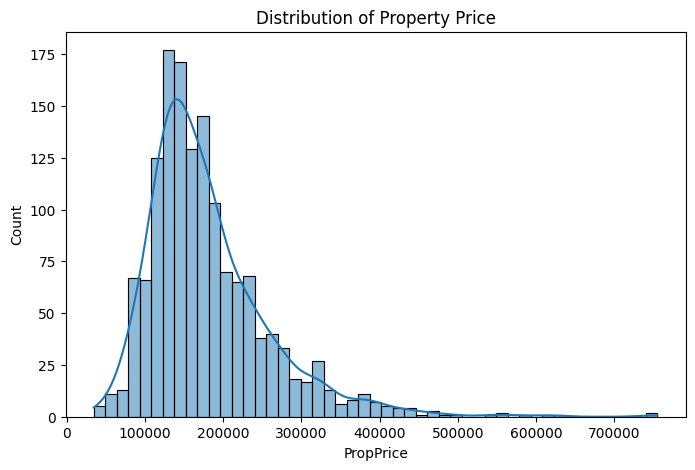

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['PropPrice'], kde=True)

plt.title('Distribution of Property Price')

plt.show()

### **Correlation Heatmap**

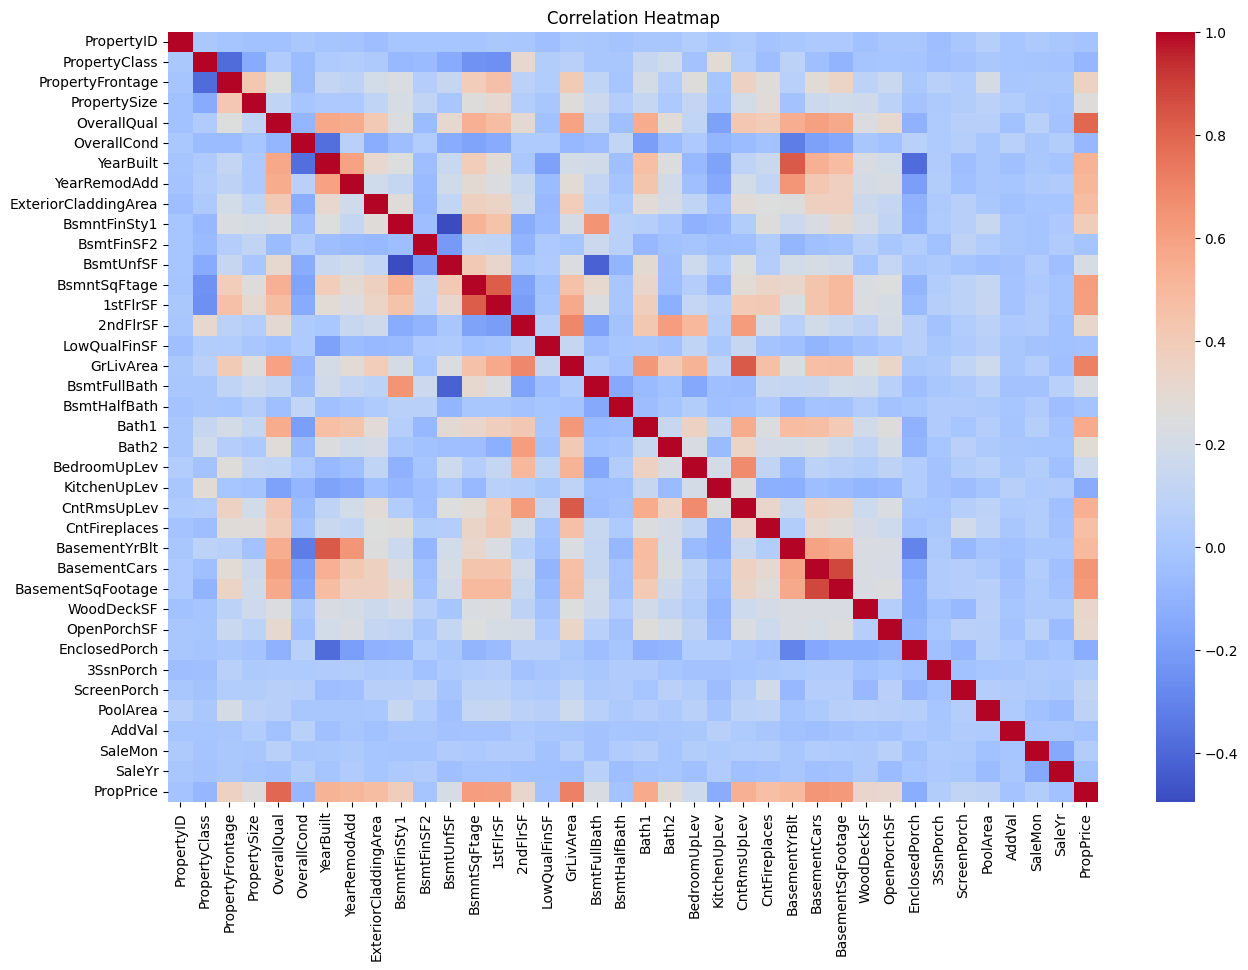

In [14]:
plt.figure(figsize=(15,10))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

### **Scatterplot Property Price vs Living Area**

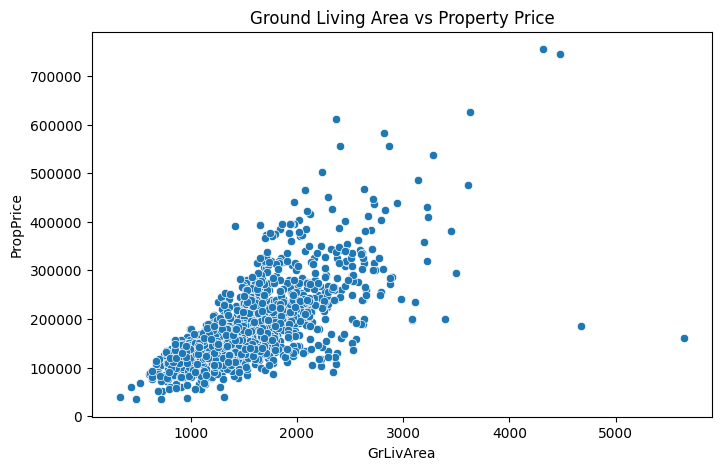

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['GrLivArea'], y=df['PropPrice'])

plt.title('Ground Living Area vs Property Price')

plt.show()

### **Boxplot Property Price vs Overall Quality**

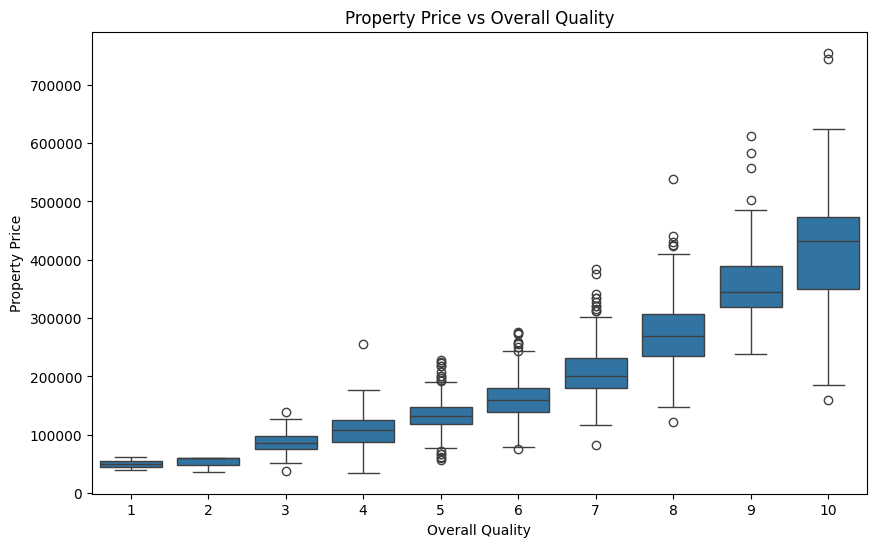

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['OverallQual'],
    y=df['PropPrice']
)

plt.title('Property Price vs Overall Quality')

plt.xlabel('Overall Quality')
plt.ylabel('Property Price')

plt.show()

### **Scatterplot Propertie Price vs Propertie Size**

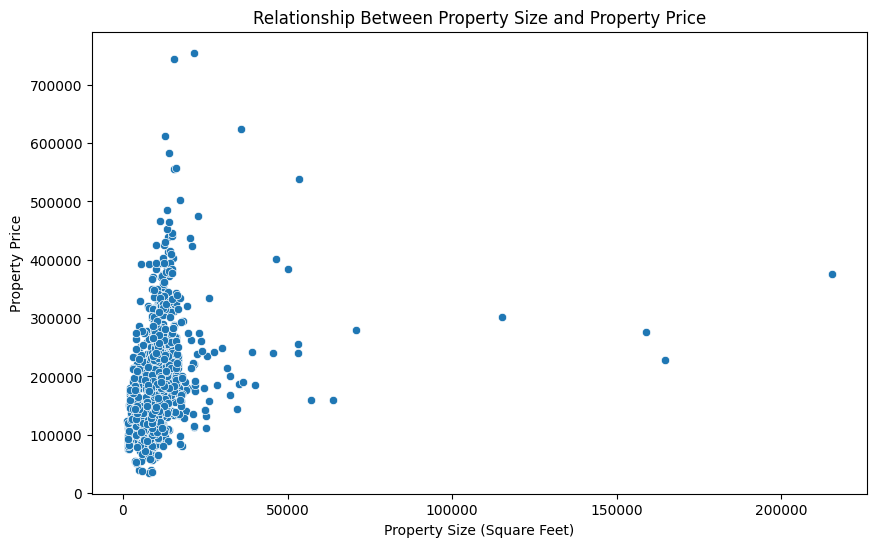

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PropertySize',
    y='PropPrice'
)

plt.title('Relationship Between Property Size and Property Price')

plt.xlabel('Property Size (Square Feet)')

plt.ylabel('Property Price')

plt.show()

### **Top Correlated Features with Target**

In [18]:
corr = df.corr(numeric_only=True)

corr_target = corr['PropPrice'].sort_values(ascending=False)

print(corr_target.head(15))

PropPrice               1.000000
OverallQual             0.790982
GrLivArea               0.708624
BasementCars            0.640409
BasementSqFootage       0.623431
BsmntSqFtage            0.613581
1stFlrSF                0.605852
Bath1                   0.560664
CntRmsUpLev             0.533723
YearBuilt               0.522897
YearRemodAdd            0.507101
BasementYrBlt           0.486362
ExteriorCladdingArea    0.477493
CntFireplaces           0.466929
BsmntFinSty1            0.386420
Name: PropPrice, dtype: float64


## **Missing Value Teratment**

### **Numerical Columns handling**

**Use median because it handles outliers & skewed data better**

In [19]:
num_cols = [
    'PropertyFrontage',
    'BasementYrBlt',
    'ExteriorCladdingArea'
]

for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

### **Normal Categorical Columns Handling**

**Use mode because it fills most frequent category**

In [20]:
df['Electrical'].fillna(
    df['Electrical'].mode()[0],
    inplace=True
)

### **Special Category**

**Fill karte hain Inme missing values ka actual meaning Feature does not exist Isliye**

In [21]:
special_cat_cols = [
    'PoolQC',
    'AddFeatures',
    'Alley',
    'BoundaryFeatures',
    'ExteriorCladdingType',
    'QualFireplace',
    'BasementType',
    'BasementFinish',
    'BasementQual',
    'BasementCond',
    'BsmntVisibility',
    'BsmntFinQual1',
    'BsmntFinish',
    'BsmntMaintenance',
    'BsmntFinRat1'
]

for col in special_cat_cols:
    df[col].fillna('None', inplace=True)

### **Re-Checking Missing values**

In [22]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0


## **Outlier Handling**

### **Boxplot for Outlier Detection**

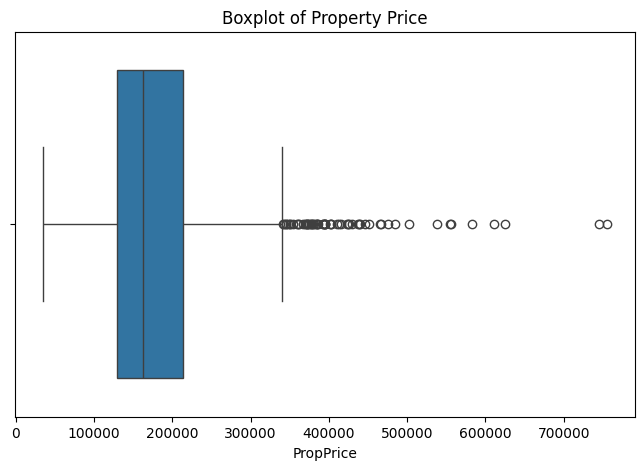

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['PropPrice'])

plt.title('Boxplot of Property Price')

plt.show()

### **Outlier Treatment With IQR Method**

In [24]:
Q1 = df['PropPrice'].quantile(0.25)
Q3 = df['PropPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers

df = df[(df['PropPrice'] >= lower_bound) &
        (df['PropPrice'] <= upper_bound)]

## **Feature Engineering**

### **Create Column Total Square Footage**

In [25]:
df['TotalSF'] = (
    df['1stFlrSF'] +
    df['2ndFlrSF'] +
    df['BsmntSqFtage']
)

### **Create Column House Age**

In [26]:
current_year = 2026

df['HouseAge'] = current_year - df['YearBuilt']

### **Create Column Total Bathrooms**

In [27]:
df['TotalBathrooms'] = (
    df['Bath1'] +
    0.5 * df['Bath2'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

## **Split Data**

### **Target and Features / Separate X and y**












In [28]:
X = df.drop('PropPrice', axis=1)

y = df['PropPrice']

**X = saare input columns, y = property price**

### **Train-Test Split**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### **Check Shapes**

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1119, 83)
(280, 83)
(1119,)
(280,)


## **Preprocessing Pipeline**

### **Separate Numerical and Categorical Columns**

In [31]:
num_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

cat_features = X_train.select_dtypes(
    include='object'
).columns.tolist()

print(f'Numerical features: {num_features}')
print(f'Categorical features: {cat_features}')

print("Numerical features :",len(num_features))
print("Categorical features :",len(cat_features))

Numerical features: ['PropertyID', 'PropertyClass', 'PropertyFrontage', 'PropertySize', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'ExteriorCladdingArea', 'BsmntFinSty1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmntSqFtage', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'Bath1', 'Bath2', 'BedroomUpLev', 'KitchenUpLev', 'CntRmsUpLev', 'CntFireplaces', 'BasementYrBlt', 'BasementCars', 'BasementSqFootage', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'AddVal', 'SaleMon', 'SaleYr', 'TotalSF', 'HouseAge', 'TotalBathrooms']
Categorical features: ['PropertyZone', 'Street', 'Alley', 'PropertyShape', 'Elevation', 'Amenities', 'Orientation', 'Grade', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'PropertyStyle', 'RoofStyle', 'RoofMatl', 'Roof1Material', 'Roof2Material', 'ExteriorCladdingType', 'ExterQual', 'ExterCond', 'PropertyFooting', 'BsmntFinish', 'BsmntMaintenance', 'BsmntVisibility', 'BsmntFinRa

### **Ordinal Columns**

In [32]:
ordinal_cols = [
    'ExterQual',
    'ExterCond',
    'HeatingEfficiency',
    'KitchenQual',
    'BsmntFinish',
    'BsmntMaintenance',
    'BsmntVisibility',
    'PoolQC',
    'BasementQual',
    'QualFireplace'
]

### **Nominal Columns**

In [33]:
nominal_cols = [
    col for col in cat_features
    if col not in ordinal_cols
]

### **Numerical Pipeline**

In [34]:
numeric_transformer = Pipeline([

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())
])

### **Ordinal Pipeline**

In [35]:
ordinal_transformer = Pipeline([

    ('imputer', SimpleImputer(
        strategy='most_frequent'
    )),

    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

### **Nominal Pipeline**

In [36]:
nominal_transformer = Pipeline([

    ('imputer', SimpleImputer(
        strategy='most_frequent'
    )),

    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

### **Combine Preprocessing**

In [37]:
preprocessor = ColumnTransformer([

    ('num',
     numeric_transformer,
     num_features),

    ('ord',
     ordinal_transformer,
     ordinal_cols),

    ('nom',
     nominal_transformer,
     nominal_cols)
])

# **Encoding**

### **Ordinal Encoding**

In [38]:
ordinal_transformer = Pipeline([

    ('imputer',
     SimpleImputer(
         strategy='most_frequent'
     )),

    ('encoder',
     OrdinalEncoder(
         handle_unknown='use_encoded_value',
         unknown_value=-1
     ))
])

### **Nominal Encoding**

In [39]:
nominal_transformer = Pipeline([

    ('imputer',
     SimpleImputer(
         strategy='most_frequent'
     )),

    ('encoder',
     OneHotEncoder(
         handle_unknown='ignore',
         sparse_output=False
     ))
])

### **Transform Data**

In [40]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

### **Check Shape After Encoding**

In [41]:
print(X_train_processed.shape)

(1119, 262)


# **Scaling**

In [42]:
scaler = StandardScaler()

## **Principal Component Analysis (PCA)**

In [43]:
pca = PCA(
    n_components=0.95
)

## **PCA Inside Pipeline Linear Regression Pipeline**

In [44]:
lr_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('pca', pca),

    ('model', LinearRegression())
])

## **Check Number of PCA Components**

In [45]:
X_train_transformed = preprocessor.fit_transform(
    X_train
)
pca.fit(X_train_transformed)


PCA(n_components=0.95)

In [46]:
print(
    'Number of Components:',
    pca.n_components_
)
print(
    'Explained Variance Ratio:',
    pca.explained_variance_ratio_
)
print(
    'Cumulative Explained Variance Ratio:',
    pca.explained_variance_ratio_.cumsum()
)

Number of Components: 67
Explained Variance Ratio: [0.17648208 0.0714994  0.06062921 0.04535771 0.03244768 0.03005546
 0.02426617 0.02186046 0.02111906 0.02076585 0.01996129 0.01983834
 0.01894557 0.01844082 0.01801931 0.01764481 0.01681129 0.01661069
 0.01625884 0.01583182 0.01523923 0.01481537 0.01405773 0.01341213
 0.0133538  0.0124894  0.01170877 0.01083351 0.01015415 0.00921747
 0.00902739 0.00801396 0.00734458 0.00685916 0.00654218 0.00608301
 0.00596891 0.00550712 0.0050238  0.00481322 0.00471461 0.00465465
 0.00449377 0.00424505 0.0041536  0.00389676 0.00372725 0.00369453
 0.00338053 0.00312769 0.00294827 0.00293754 0.00275974 0.00266069
 0.00259274 0.00252783 0.00235735 0.00228561 0.00224909 0.00213732
 0.00208373 0.00189848 0.00181011 0.0017765  0.00169633 0.00165683
 0.001622  ]
Cumulative Explained Variance Ratio: [0.17648208 0.24798149 0.3086107  0.35396841 0.38641609 0.41647155
 0.44073772 0.46259818 0.48371724 0.50448309 0.52444439 0.54428272
 0.56322829 0.58166911 0.599

### **Cumulative Variance Plot**

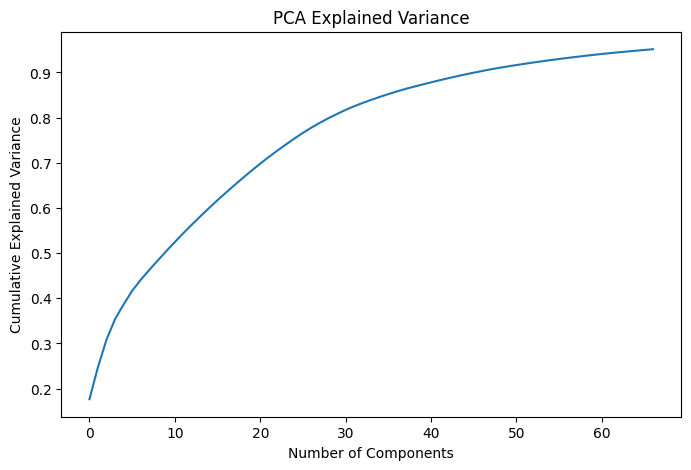

In [47]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(cumulative_variance)

plt.xlabel('Number of Components')

plt.ylabel('Cumulative Explained Variance')

plt.title('PCA Explained Variance')

plt.show()

## **PCA Pipeline**

In [48]:
pca = PCA(
    n_components=0.95
)

lr_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('pca', pca),

    ('model', LinearRegression())
])

lr_pipeline.fit(
    X_train,
    y_train
)

lr_pred = lr_pipeline.predict(
    X_test
)
print('preprocessor', preprocessor)
print('pca', pca)
print('model', lr_pipeline.named_steps['model'])
print(r2_score(y_test, lr_pred))
print(
    'Number of Components:',
    pca.n_components_
)
print(
    pca.explained_variance_ratio_
)
print(
    'Cumulative Explained Variance:',
    np.cumsum(pca.explained_variance_ratio_)
)


preprocessor ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['PropertyID', 'PropertyClass',
                                  'PropertyFrontage', 'PropertySize',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'ExteriorCladdingArea',
                                  'BsmntFinSty1', 'BsmtFinSF2', 'BsmtUnfSF',
                                  'BsmntSqFtage', '1stFlrSF', '2ndFlrSF',
                                  '...
                                  'Orientation', 'Grade', 'Neighborhood',
                                  'Condition1', 'Condition2', 'BldgType',
                                  'PropertyStyle', 'RoofStyle', 'RoofMatl',
                    

# **Model Building**

## **Linear Regression Pipeline**

In [49]:
lr_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('pca', PCA(n_components=0.95)),

    ('model', LinearRegression())
])

## **Decision Tree Pipeline**

In [50]:
dt_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('pca', PCA(n_components=0.95)),

    ('model',
     DecisionTreeRegressor(
         random_state=42,
         max_depth=10
     ))
])

## **Random Forest Pipeline**

In [51]:
rf_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('pca', PCA(n_components=0.95)),

    ('model',
     RandomForestRegressor(
         n_estimators=200,
         max_depth=20,
         min_samples_split=5,
         random_state=42,
         n_jobs=-1
     ))
])

## **Gradient Boosting Pipeline**

In [52]:
gb_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('pca', PCA(n_components=0.95)),

    ('model',
     GradientBoostingRegressor(
         n_estimators=100,
         learning_rate=0.1,
         max_depth=5,
         random_state=42
     ))
])

## **Train All Models**

In [53]:
lr_pipeline.fit(
    X_train,
    y_train
)

dt_pipeline.fit(
    X_train,
    y_train
)

rf_pipeline.fit(
    X_train,
    y_train
)

gb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PropertyID',
                                                   'PropertyClass',
                                                   'PropertyFrontage',
                                                   'PropertySize',
                                                   'OverallQual', 'OverallCond',
                                                   'YearBuilt', 'YearRemodAdd',
                                                   'ExteriorCladdingArea',
                                                   'BsmntFinSty1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'Bsmnt...
                                                   'PropertyStyle', 'RoofStyle',
                                                   'RoofMatl', 'Roof1Material',
                                                   'Roof2Material',
                                                   'ExteriorCladdingType',
                                                   'PropertyFooting',
                                                   'BsmntFinRat1',
                                                   'BsmntFinQual1', 'Heating',
                                                   'CentralAir', 'Electrical',
                                                   'Functional', 'BasementType',
                                                   'BasementFinish',
                                                   'BasementCond', 'PavedDrive',
                                                   'BoundaryFeatures', ...])])),
                ('pca', PCA(n_components=0.95)),
                ('model',
                 GradientBoostingRegressor(max_depth=5, random_state=42))])

# **Predictions**

In [54]:
lr_pred = lr_pipeline.predict(
    X_test
)

dt_pred = dt_pipeline.predict(
    X_test
)

rf_pred = rf_pipeline.predict(
    X_test
)

gb_pred = gb_pipeline.predict(
    X_test
)

# **Model Evaluation**

In [55]:
models = {
    'Linear Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred
}

for name, pred in models.items():

    print(f'===== {name} =====')

    print(
        'R2 Score:',
        r2_score(y_test, pred)
    )

    print(
        'MAE:',
        mean_absolute_error(
            y_test,
            pred
        )
    )

    print(
        'RMSE:',
        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )
    )

    print()

===== Linear Regression =====
R2 Score: 0.8700524752321915
MAE: 14869.951009100716
RMSE: 20330.74881917727

===== Decision Tree =====
R2 Score: 0.7124241864163481
MAE: 21297.706443307263
RMSE: 30244.440000735627

===== Random Forest =====
R2 Score: 0.8574444953243321
MAE: 15256.019319946072
RMSE: 21294.201778587765

===== Gradient Boosting =====
R2 Score: 0.8786286730206854
MAE: 14099.417939781815
RMSE: 19648.41032801656



## **Select Best Model**

In [56]:
best_model = lr_pipeline

# **Cross Validation**

In [57]:
cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print('Cross Validation Scores:', cv_scores)

print('Average CV Score:', cv_scores.mean())

Cross Validation Scores: [0.8570363  0.81410923 0.85495382 0.86225952 0.64692482]
Average CV Score: 0.80705674084517


## **Hyperparameter Tuning**

In [58]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]
}

In [59]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

In [60]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['PropertyID',
                                                                          'PropertyClass',
                                                                          'PropertyFrontage',
                                                                          'PropertySize',
                                                                          'OverallQual',
                                                                          'OverallCond',
                                                                          'YearBuilt',
                                                                          'YearRemodAdd',
                                                                          'ExteriorCladdingArea',
                                                                          'BsmntFinSty1',
                                                                          'Bs...
                                                                          'BasementType',
                                                                          'BasementFinish',
                                                                          'BasementCond',
                                                                          'PavedDrive',
                                                                          'BoundaryFeatures', ...])])),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        RandomForestRegressor(max_depth=20,
                                                              min_samples_split=5,
                                                              n_estimators=200,
                                                              n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20, None],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [61]:
print('Best Parameters:', grid_search.best_params_)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}


## **Feature Importance Analysis**

In [62]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ],

    'MAE': [
        mean_absolute_error(
            y_test,
            lr_pred
        ),

        mean_absolute_error(
            y_test,
            dt_pred
        ),

        mean_absolute_error(
            y_test,
            rf_pred
        ),

        mean_absolute_error(
            y_test,
            gb_pred
        )
    ],

    'RMSE': [
        np.sqrt(
            mean_squared_error(
                y_test,
                lr_pred
            )
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                dt_pred
            )
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                rf_pred
            )
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                gb_pred
            )
        )
    ]
})

In [63]:
results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score,MAE,RMSE
3,Gradient Boosting,0.878629,14099.417940,19648.410328
0,Linear Regression,0.870052,14869.951009,20330.748819
2,Random Forest,0.857444,15256.019320,21294.201779
1,Decision Tree,0.712424,21297.706443,30244.440001


# **Actual vs Predicted Visualization**

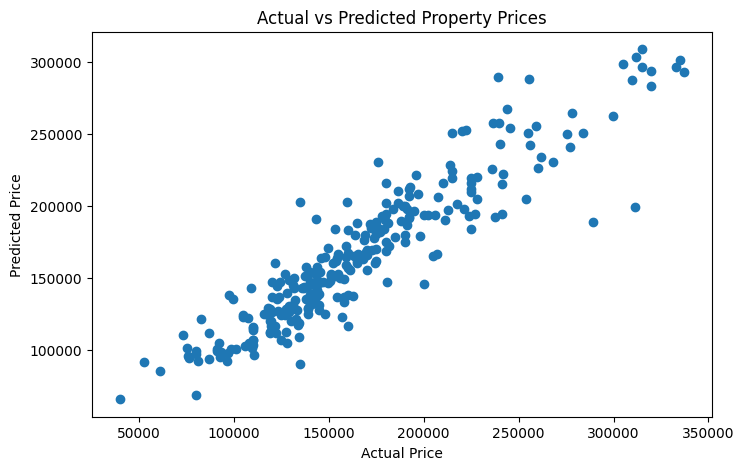

In [64]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.title(
    'Actual vs Predicted Property Prices'
)

plt.show()

# **Final Best Model Selection**

In [65]:
best_model = lr_pipeline

# **Save Model**

In [66]:
import joblib

joblib.dump(
    lr_pipeline,
    'property_price_model.pkl'
)

['property_price_model.pkl']